In [24]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
from scipy.integrate import odeint

In [25]:
def test_int(X, t, betat, gamma, mu):
    S = -betat(t)*X[0]*X[1]-mu*X[0]+mu
    I = betat(t)*X[0]*X[1]-(mu+gamma)*X[1]
    R = gamma*X[1]-mu*X[2]

    A = np.matrix([[-betat(t)*X[1]-mu,-betat(t)*X[0]], 
                   [betat(t)*X[1],-(gamma+mu)+betat(t)*X[0]],
                   ])
    B = np.matrix([[betat(t)*X[0]*X[1]+mu*X[0]+mu,-betat(t)*X[0]*X[1]],
                   [-betat(t)*X[0]*X[1],betat(t)*X[0]*X[1]+(gamma+mu)*X[1]],
                   ])

    Θ = np.matrix([[X[3],X[4]],
                   [X[4],X[5]],
                   ])

    K = A*Θ +Θ*A.transpose()+B
    return [S, I, R, K[0,0], K[0,1], K[1,1]]

def jac(X, t, betat, gamma, mu):
    A = np.matrix([[-betat(t)*X[1]-mu,-betat(t)*X[0]], 
                   [betat(t)*X[1],-(gamma+mu)+betat(t)*X[0]],
                   ])
    return A

def Q_calc(X, t, betat, gamma, mu):
    B = np.matrix([[betat(t)*X[0]*X[1]+mu*X[0]+mu,-betat(t)*X[0]*X[1]],
                   [-betat(t)*X[0]*X[1],betat(t)*X[0]*X[1]+(gamma+mu)*X[1]],
                   ])
    return B

def test_int_multin(X, t, betat, gamma, mu):
    S = -betat(t)*X[0]*X[1]-mu*X[0]+mu
    I = betat(t)*X[0]*X[1]-(mu+gamma)*X[1]
    R = gamma*X[1]-mu*X[2]

    A = np.matrix([[-betat(t)*X[1]-mu,-betat(t)*X[0],0], 
                   [betat(t)*X[1],-(gamma+mu)+betat(t)*X[0],0],
                   [0, gamma, -mu]])
    B = np.matrix([[betat(t)*X[0]*X[1]+mu*X[0]+mu,-betat(t)*X[0]*X[1],0],
                   [-betat(t)*X[0]*X[1],betat(t)*X[0]*X[1]+(gamma+mu)*X[1],-gamma*X[1]],
                   [0,-gamma*X[1],gamma*X[1]+mu*X[2]]])

    Θ = np.matrix([[X[3],X[4],X[5]],
                   [X[4],X[6],X[7]],
                   [X[5],X[7],X[8]]])

    K = A*Θ +Θ*A.transpose()+B
    return [S, I, R, K[0,0], K[0,1], K[0,2], K[1,1], K[1,2], K[2,2]]

In [26]:
file_list = glob.glob('Sim_results/low/1000/I*.npy')
for i, file in enumerate(file_list):
    low_1000 = np.load(file) if i == 0 else np.vstack((low_1000,np.load(file)))
low_1000 = low_1000 / 1000
df_1000 = pd.DataFrame(low_1000).T
stoch_cst = df_1000.sub(df_1000.mean(axis = 1), axis = 'rows')
df_1000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/low/10000/I*.npy')
for i, file in enumerate(file_list):
    low_10000 = np.load(file) if i == 0 else np.vstack((low_10000,np.load(file)))
low_10000 = low_10000 / 10000
df_10000 = pd.DataFrame(low_10000).T
stoch_cst = df_10000.sub(df_10000.mean(axis = 1), axis = 'rows')
df_10000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/low/100000/I*.npy')
for i, file in enumerate(file_list):
    low_100000 = np.load(file) if i == 0 else np.vstack((low_100000,np.load(file)))
low_100000 = low_100000 / 100000
df_100000 = pd.DataFrame(low_100000).T
stoch_cst = df_100000.sub(df_100000.mean(axis = 1), axis = 'rows')
df_100000_var = stoch_cst.var(axis=1).values

In [27]:
N = 1e5  # Total population
gamma = 1/14  # Recovery rate (1/gamma is the infectious period)
mu = 0.00003424657  # Birth and death rate
beta0 = 0.06
betat = lambda x: beta0
ts = np.linspace(0,250,2501)
X0 = [0.9, 0.1, 0, 0, 0, 0]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
S, I, R = sol[:,0], sol[:,1], sol[:,2]
Sigma11, Sigma12, Sigma22 = sol[:,3], sol[:,4], sol[:,5]
days = np.arange(0,251)

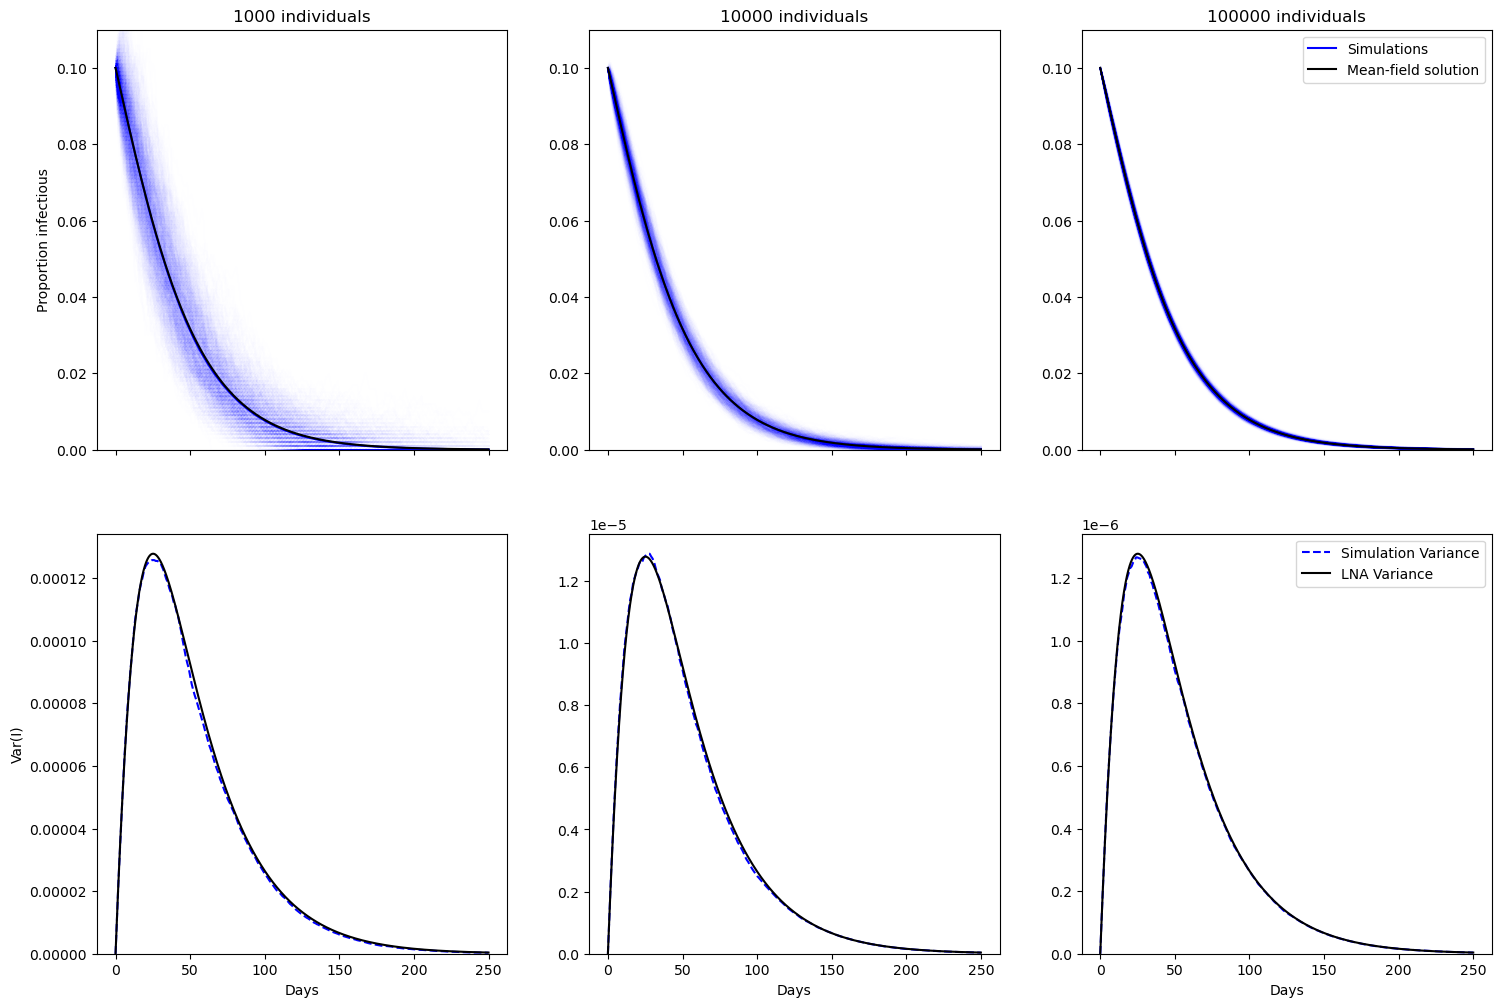

In [28]:
fig, axs = plt.subplots(2, 3, figsize=(18, 12), sharex=True)
axs[0,0].plot(days, df_1000.values[:,::10], color = 'b', alpha = 0.005)
axs[0,0].plot(days, df_1000.mean(axis = 1), color = 'b')
axs[0,0].plot(ts, I, color = 'k')
axs[0,1].plot(days, df_10000.values[:,::10], color = 'b',alpha = 0.005)
axs[0,1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[0,1].plot(ts, I, color = 'k')
axs[0,2].plot(days, df_100000.values[:,::10], color = 'b', alpha = 0.005)
axs[0,2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[0,2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[1,0].plot(days, df_1000_var, color = 'b', linestyle = '--')
axs[1,0].plot(ts, Sigma22/1000, color = 'k')
axs[1,1].plot(days, df_10000_var, color = 'b', linestyle = '--')
axs[1,1].plot(ts, Sigma22/10000, color = 'k')
axs[1,2].plot(days, df_100000_var, color = 'b', linestyle = '--', label = 'Simulation Variance')
axs[1,2].plot(ts, Sigma22/100000, color = 'k', label='LNA Variance')
pop_size = [1000,10000,100000]
row_title = ['Proportion infectious','Var(I)']
for j in range(3):
    axs[0,j].set_ylim(0,0.11)
    axs[1,j].set_ylim(0,None)
    axs[0,j].set_title(f'{pop_size[j]} individuals')
    axs[1,j].set_xlabel('Days')
    if j == 2:
        axs[0,j].legend()
        axs[1,j].legend()
for i in range(2):
    axs[i,0].set_ylabel(row_title[i])
plt.show()

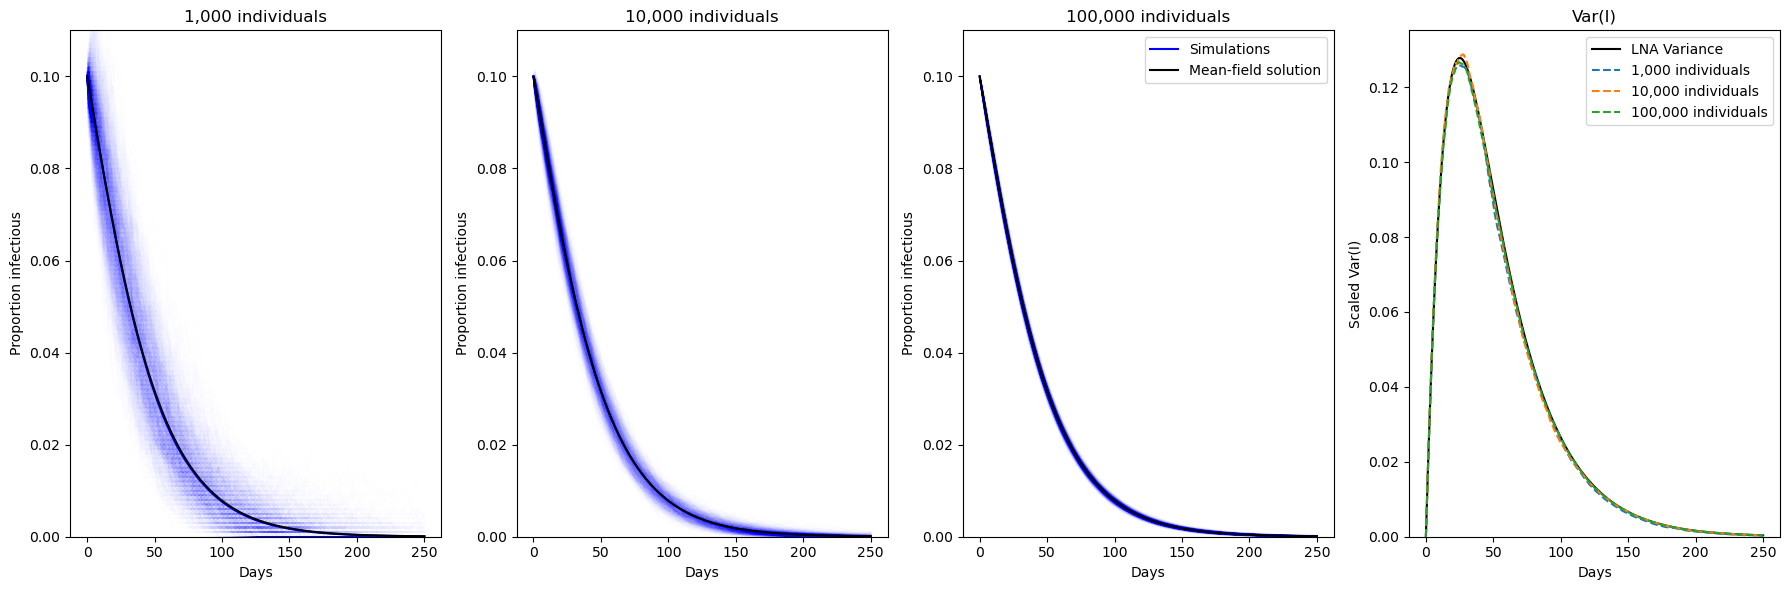

In [29]:
fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, df_1000.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, df_1000.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_10000.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_100000.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigma22, color = 'k', label='LNA Variance')
axs[3].plot(days, df_1000_var*1000, linestyle = '--', label = '1,000 individuals')
axs[3].plot(days, df_10000_var*10000, linestyle = '--', label = '10,000 individuals')
axs[3].plot(days, df_100000_var*100000, linestyle = '--', label = '100,000 individuals')
pop_size = ['1,000','10,000','100,000']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.11),(0,0.11),(0,0.11),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]} individuals')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

In [30]:
file_list = glob.glob('Sim_results/lowrand/1000/I*.npy')
for i, file in enumerate(file_list):
    low_1000 = np.load(file) if i == 0 else np.vstack((low_1000,np.load(file)))
low_1000 = low_1000 / 1000
df_1000 = pd.DataFrame(low_1000).T
stoch_cst = df_1000.sub(df_1000.mean(axis = 1), axis = 'rows')
df_1000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/lowrand/10000/I*.npy')
for i, file in enumerate(file_list):
    low_10000 = np.load(file) if i == 0 else np.vstack((low_10000,np.load(file)))
low_10000 = low_10000 / 10000
df_10000 = pd.DataFrame(low_10000).T
stoch_cst = df_10000.sub(df_10000.mean(axis = 1), axis = 'rows')
df_10000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/lowrand/100000/I*.npy')
for i, file in enumerate(file_list):
    low_100000 = np.load(file) if i == 0 else np.vstack((low_100000,np.load(file)))
low_100000 = low_100000 / 100000
df_100000 = pd.DataFrame(low_100000).T
stoch_cst = df_100000.sub(df_100000.mean(axis = 1), axis = 'rows')
df_100000_var = stoch_cst.var(axis=1).values

In [31]:
ps = np.array([0.9,0.1,0])
init_var = np.diag(ps) - np.outer(ps,ps)

X0 = [0.9, 0.1, 0, init_var[0,0], init_var[0,1], init_var[0,2], init_var[1,1], init_var[1,2], init_var[2,2]]
sol = odeint(test_int_multin, X0, ts, args=(betat, gamma, mu))
S, I, R = sol[:,0], sol[:,1], sol[:,2]
Sigma22 = sol[:,6]
days = np.arange(0,251)

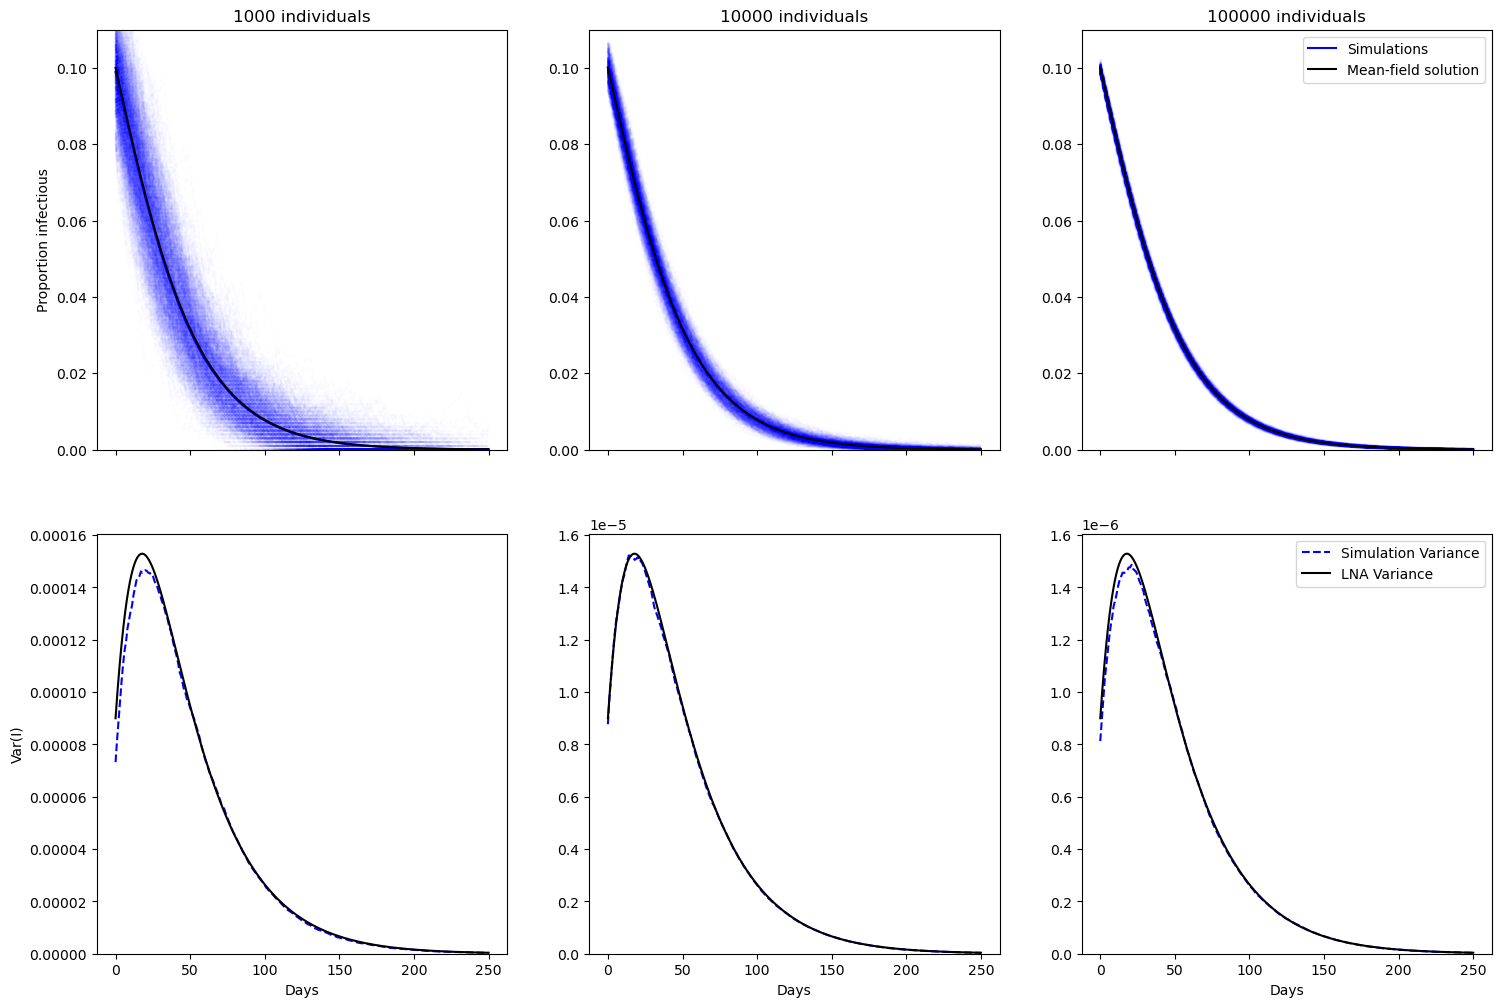

In [32]:
fig, axs = plt.subplots(2, 3, figsize=(18, 12), sharex=True)
axs[0,0].plot(days, df_1000.values[:,::10], color = 'b', linestyle = '--', alpha = 0.01)
axs[0,0].plot(days, df_1000.mean(axis = 1), color = 'b')
axs[0,0].plot(ts, I, color = 'k')
axs[0,1].plot(days, df_10000.values[:,::10], color = 'b', linestyle = '--', alpha = 0.01)
axs[0,1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[0,1].plot(ts, I, color = 'k')
axs[0,2].plot(days, df_100000.values[:,::10], color = 'b', linestyle = '--', alpha = 0.01)
axs[0,2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[0,2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[1,0].plot(days, df_1000_var, color = 'b', linestyle = '--')
axs[1,0].plot(ts, Sigma22/1000, color = 'k')
axs[1,1].plot(days, df_10000_var, color = 'b', linestyle = '--')
axs[1,1].plot(ts, Sigma22/10000, color = 'k')
axs[1,2].plot(days, df_100000_var, color = 'b', linestyle = '--', label = 'Simulation Variance')
axs[1,2].plot(ts, Sigma22/100000, color = 'k', label='LNA Variance')
pop_size = [1000,10000,100000]
row_title = ['Proportion infectious','Var(I)']
for j in range(3):
    axs[0,j].set_ylim(0,0.11)
    axs[1,j].set_ylim(0,None)
    axs[0,j].set_title(f'{pop_size[j]} individuals')
    axs[1,j].set_xlabel('Days')
    if j == 2:
        axs[0,j].legend()
        axs[1,j].legend()
for i in range(2):
    axs[i,0].set_ylabel(row_title[i])
plt.show()

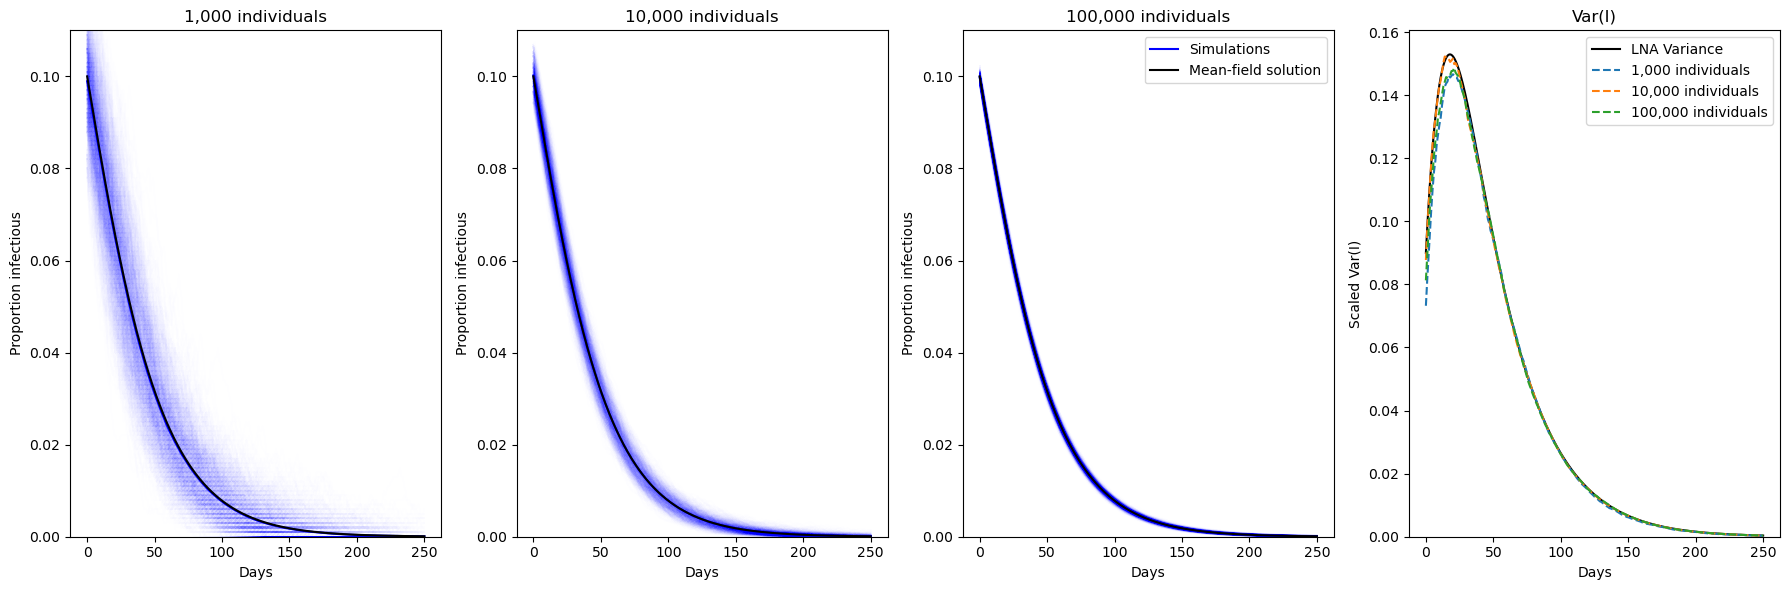

In [33]:
fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, df_1000.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, df_1000.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_10000.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_100000.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigma22, color = 'k', label='LNA Variance')
axs[3].plot(days, df_1000_var*1000, linestyle = '--', label = '1,000 individuals')
axs[3].plot(days, df_10000_var*10000, linestyle = '--', label = '10,000 individuals')
axs[3].plot(days, df_100000_var*100000, linestyle = '--', label = '100,000 individuals')
pop_size = ['1,000','10,000','100,000']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.11),(0,0.11),(0,0.11),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]} individuals')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

In [34]:
file_list = glob.glob('Sim_results/lownorm/10000/0.1/I*.npy')
for i, file in enumerate(file_list):
    low_n = np.load(file) if i == 0 else np.vstack((low_n,np.load(file)))
low_n = low_n / 1000
df_1 = pd.DataFrame(low_n).T
stoch_cst = df_1.sub(df_1.mean(axis = 1), axis = 'rows')
df_1_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/lownorm/10000/0.25/I*.npy')
for i, file in enumerate(file_list):
    med_n = np.load(file) if i == 0 else np.vstack((med_n,np.load(file)))
med_n = med_n / 10000
df_25 = pd.DataFrame(med_n).T
stoch_cst = df_25.sub(df_25.mean(axis = 1), axis = 'rows')
df_25_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/lownorm/10000/0.5/I*.npy')
for i, file in enumerate(file_list):
    high_n = np.load(file) if i == 0 else np.vstack((high_n,np.load(file)))
high_n = high_n / 100000
df_5 = pd.DataFrame(high_n).T
stoch_cst = df_5.sub(df_5.mean(axis = 1), axis = 'rows')
df_5_var = stoch_cst.var(axis=1).values

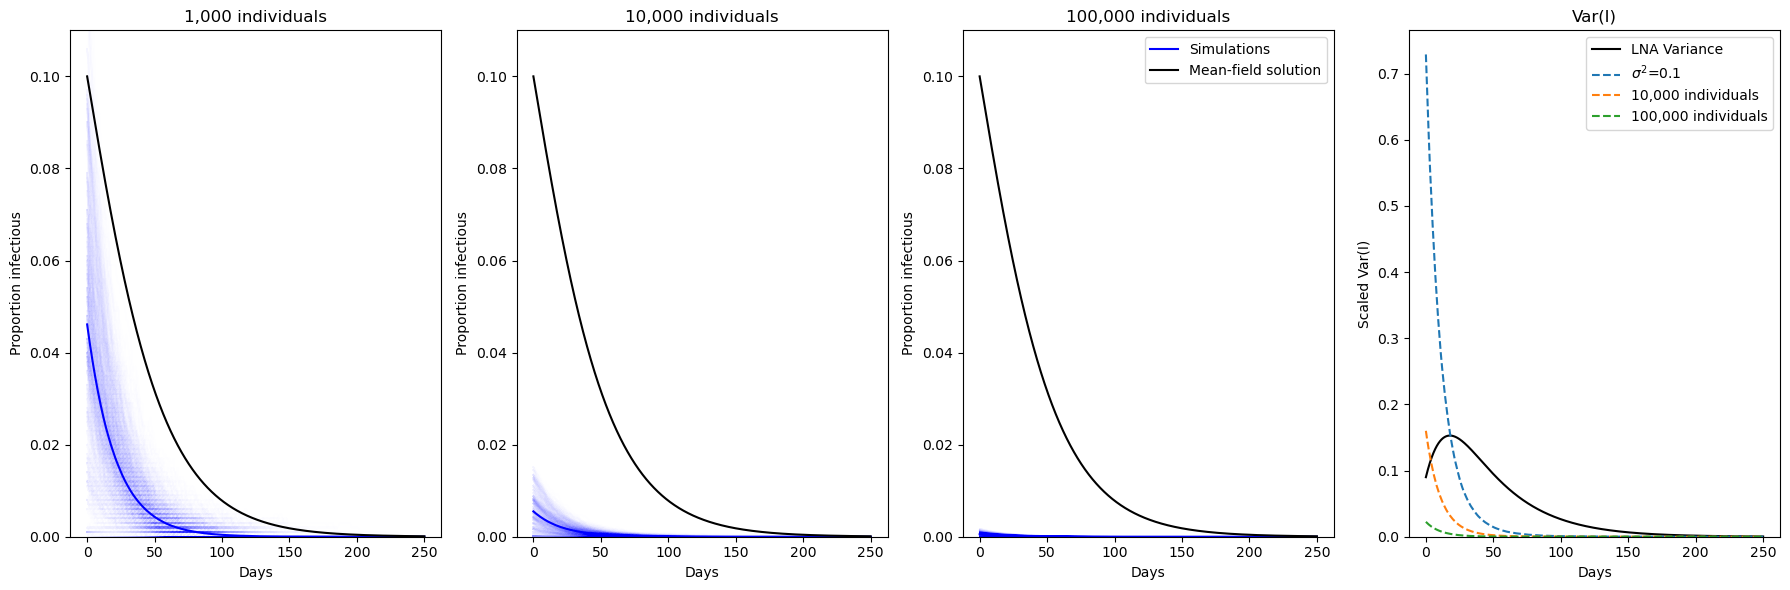

In [35]:
fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, df_1.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, df_1.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_25.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_25.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_5.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_5.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigma22, color = 'k', label='LNA Variance')
axs[3].plot(days, df_1_var*1000, linestyle = '--', label = f'$\sigma^2$=0.1')
axs[3].plot(days, df_25_var*10000, linestyle = '--', label = '10,000 individuals')
axs[3].plot(days, df_5_var*100000, linestyle = '--', label = '100,000 individuals')
pop_size = ['1,000','10,000','100,000']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.11),(0,0.11),(0,0.11),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]} individuals')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

In [37]:
# Change estimates slightly for SIR model
N = 1e5  # Total population
gamma = 1/14  # Recovery rate (1/gamma is the infectious period)
R_0 = 4 # Basic reproduction number estimated for alpha variant
mu = 0.00003424657  # Birth and death rate
beta0 = R_0 * (gamma+mu)
betat = lambda x: beta0
X0 = [0.4, 0.005, 1-0.4-0.005, 0, 0, 0]
sol = odeint(test_int, X0, ts, args=(betat, gamma, mu))
S, I, R = sol[:,0], sol[:,1], sol[:,2]
Sigma11, Sigma12, Sigma22 = sol[:,3], sol[:,4], sol[:,5]
days = np.arange(0,251)

In [38]:
file_list = glob.glob('Sim_results/high/1000/I*.npy')
for i, file in enumerate(file_list):
    high_1000 = np.load(file) if i == 0 else np.vstack((high_1000,np.load(file)))
high_1000 = high_1000 / 1000
df_1000 = pd.DataFrame(high_1000).T
stoch_cst = df_1000.sub(df_1000.mean(axis = 1), axis = 'rows')
df_1000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/high/10000/I*.npy')
for i, file in enumerate(file_list):
    high_10000 = np.load(file) if i == 0 else np.vstack((high_10000,np.load(file)))
high_10000 = high_10000 / 10000
df_10000 = pd.DataFrame(high_10000).T
stoch_cst = df_10000.sub(df_10000.mean(axis = 1), axis = 'rows')
df_10000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/high/100000/I*.npy')
for i, file in enumerate(file_list):
    high_100000 = np.load(file) if i == 0 else np.vstack((high_100000,np.load(file)))
high_100000 = high_100000 / 100000
df_100000 = pd.DataFrame(high_100000).T
stoch_cst = df_100000.sub(df_100000.mean(axis = 1), axis = 'rows')
df_100000_var = stoch_cst.var(axis=1).values

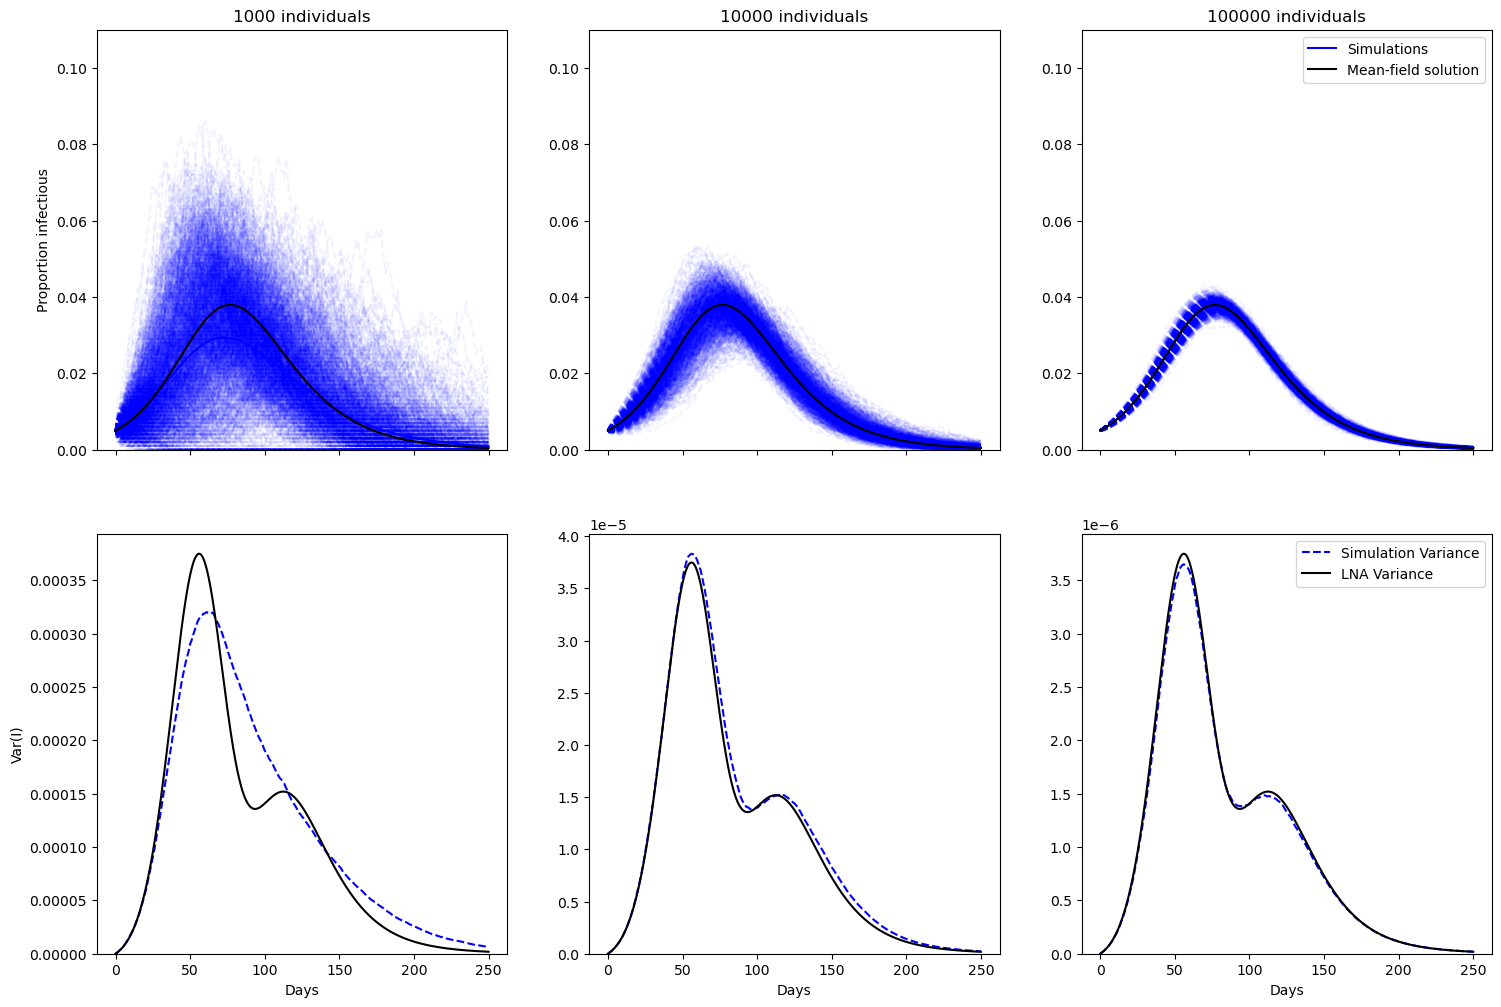

In [39]:
fig, axs = plt.subplots(2, 3, figsize=(18, 12), sharex=True)
axs[0,0].plot(days, df_1000.values[:,::10], color = 'b', linestyle = '--', alpha = 0.05)
axs[0,0].plot(days, df_1000.mean(axis = 1), color = 'b')
axs[0,0].plot(ts, I, color = 'k')
axs[0,1].plot(days, df_10000.values[:,::10], color = 'b', linestyle = '--', alpha = 0.05)
axs[0,1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[0,1].plot(ts, I, color = 'k')
axs[0,2].plot(days, df_100000.values[:,::10], color = 'b', linestyle = '--', alpha = 0.05)
axs[0,2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[0,2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[1,0].plot(days, df_1000_var, color = 'b', linestyle = '--')
axs[1,0].plot(ts, Sigma22/1000, color = 'k')
axs[1,1].plot(days, df_10000_var, color = 'b', linestyle = '--')
axs[1,1].plot(ts, Sigma22/10000, color = 'k')
axs[1,2].plot(days, df_100000_var, color = 'b', linestyle = '--', label = 'Simulation Variance')
axs[1,2].plot(ts, Sigma22/100000, color = 'k', label='LNA Variance')
pop_size = [1000,10000,100000]
row_title = ['Proportion infectious','Var(I)']
for j in range(3):
    axs[0,j].set_ylim(0,0.11)
    axs[1,j].set_ylim(0,None)
    axs[0,j].set_title(f'{pop_size[j]} individuals')
    axs[1,j].set_xlabel('Days')
    if j == 2:
        axs[0,j].legend()
        axs[1,j].legend()
for i in range(2):
    axs[i,0].set_ylabel(row_title[i])
plt.show()

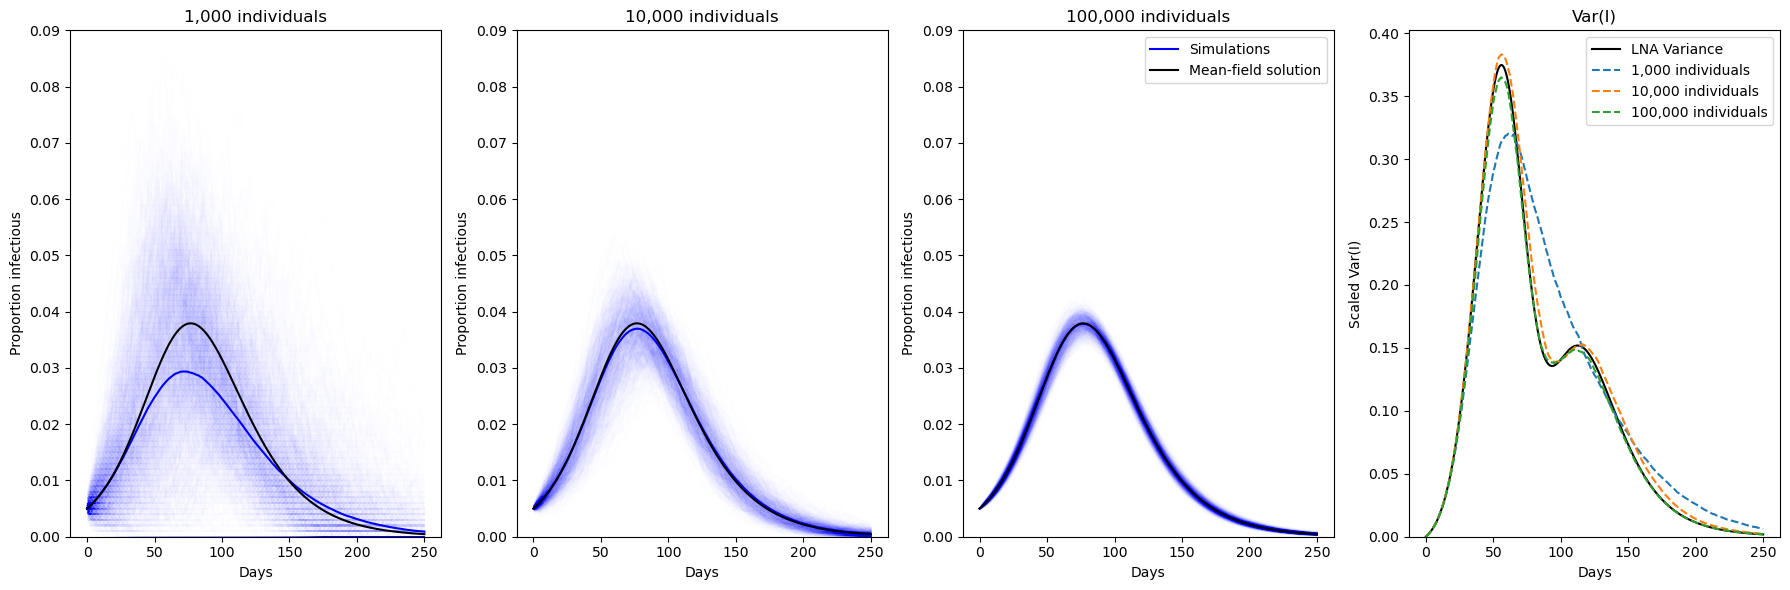

In [40]:
fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, df_1000.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, df_1000.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_10000.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_100000.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigma22, color = 'k', label='LNA Variance')
axs[3].plot(days, df_1000_var*1000, linestyle = '--', label = '1,000 individuals')
axs[3].plot(days, df_10000_var*10000, linestyle = '--', label = '10,000 individuals')
axs[3].plot(days, df_100000_var*100000, linestyle = '--', label = '100,000 individuals')
pop_size = ['1,000','10,000','100,000']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.09),(0,0.09),(0,0.09),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]} individuals')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

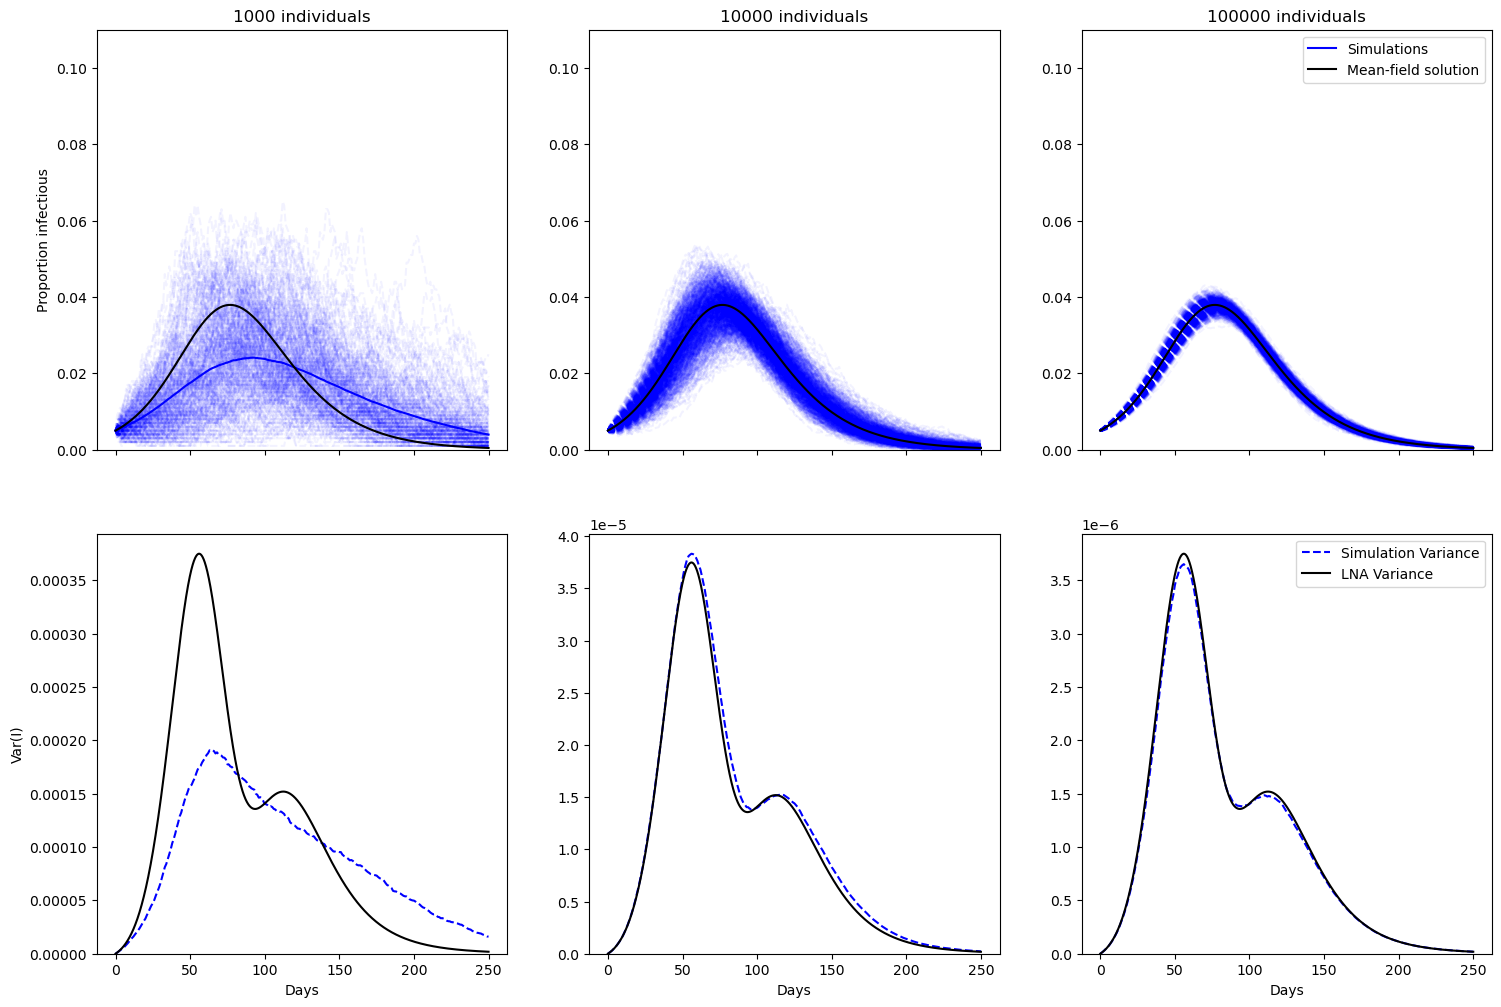

In [41]:
np.sum(high_1000[:,-1]!= 0)
test_high_1000 = high_1000[np.where(high_1000[:,-1] != 0)]
test_df_1000 = pd.DataFrame(test_high_1000).T
test_stoch_cst = test_df_1000.sub(test_df_1000.mean(axis = 1), axis = 'rows')
test_df_1000_var = test_stoch_cst.var(axis=1).values
fig, axs = plt.subplots(2, 3, figsize=(18, 12), sharex=True)
axs[0,0].plot(days, test_df_1000.values[:,::10], color = 'b', linestyle = '--', alpha = 0.05)
axs[0,0].plot(days, test_df_1000.mean(axis = 1), color = 'b')
axs[0,0].plot(ts, I, color = 'k')
axs[0,1].plot(days, df_10000.values[:,::10], color = 'b', linestyle = '--', alpha = 0.05)
axs[0,1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[0,1].plot(ts, I, color = 'k')
axs[0,2].plot(days, df_100000.values[:,::10], color = 'b', linestyle = '--', alpha = 0.05)
axs[0,2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[0,2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[1,0].plot(days, test_df_1000_var, color = 'b', linestyle = '--')
axs[1,0].plot(ts, Sigma22/1000, color = 'k')
axs[1,1].plot(days, df_10000_var, color = 'b', linestyle = '--')
axs[1,1].plot(ts, Sigma22/10000, color = 'k')
axs[1,2].plot(days, df_100000_var, color = 'b', linestyle = '--', label = 'Simulation Variance')
axs[1,2].plot(ts, Sigma22/100000, color = 'k', label='LNA Variance')
pop_size = [1000,10000,100000]
row_title = ['Proportion infectious','Var(I)']
for j in range(3):
    axs[0,j].set_ylim(0,0.11)
    axs[1,j].set_ylim(0,None)
    axs[0,j].set_title(f'{pop_size[j]} individuals')
    axs[1,j].set_xlabel('Days')
    if j == 2:
        axs[0,j].legend()
        axs[1,j].legend()
for i in range(2):
    axs[i,0].set_ylabel(row_title[i])
plt.show()

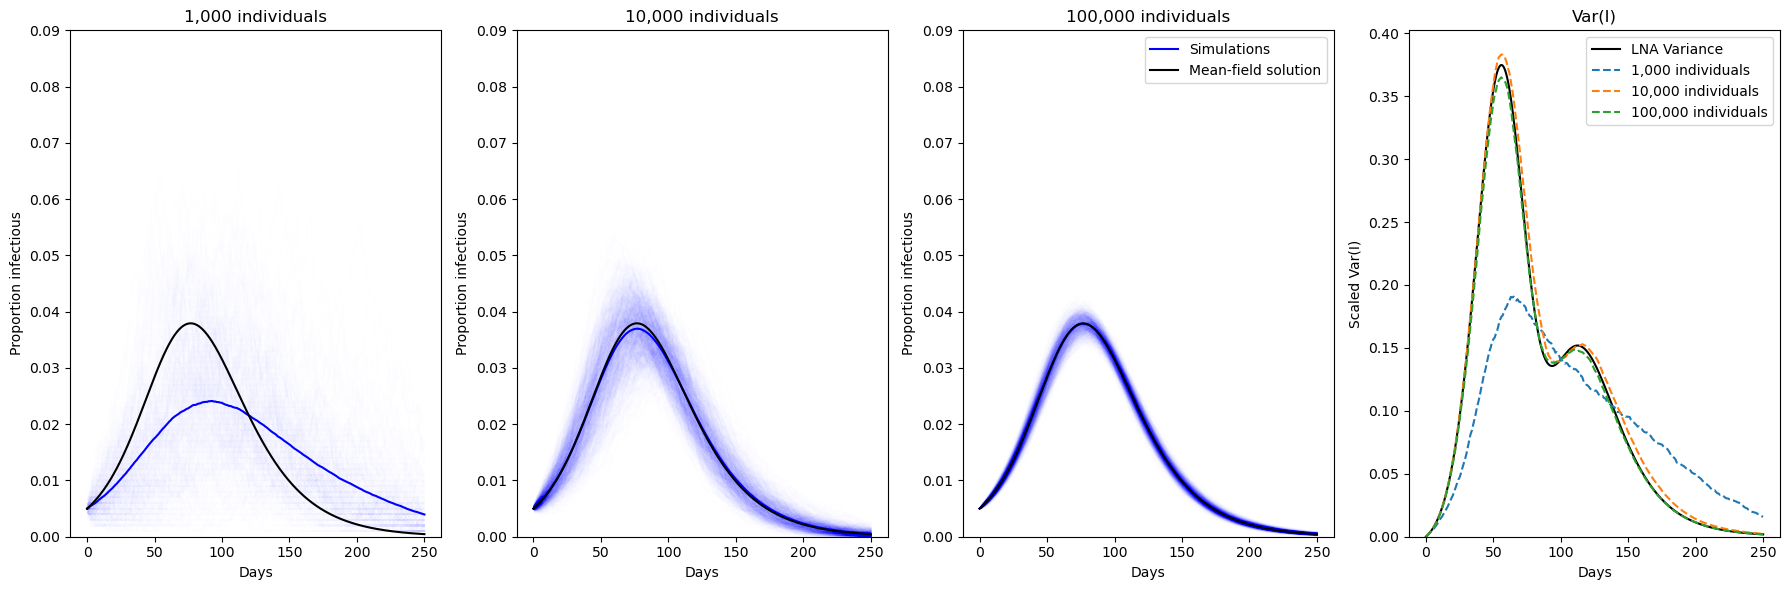

In [42]:
test_high_1000 = high_1000[np.where(high_1000[:,-1] != 0)]
test_df_1000 = pd.DataFrame(test_high_1000).T
test_stoch_cst = test_df_1000.sub(test_df_1000.mean(axis = 1), axis = 'rows')
test_df_1000_var = test_stoch_cst.var(axis=1).values
fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, test_df_1000.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, test_df_1000.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_10000.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_100000.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigma22, color = 'k', label='LNA Variance')
axs[3].plot(days, test_df_1000_var*1000, linestyle = '--', label = '1,000 individuals')
axs[3].plot(days, df_10000_var*10000, linestyle = '--', label = '10,000 individuals')
axs[3].plot(days, df_100000_var*100000, linestyle = '--', label = '100,000 individuals')
pop_size = ['1,000','10,000','100,000']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.09),(0,0.09),(0,0.09),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]} individuals')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

In [43]:
ps = np.array([0.4, 0.005, 1-0.4-0.005])
init_var = np.diag(ps) - np.outer(ps,ps)
X0 = [0.4, 0.005, 1-0.4-0.005, init_var[0,0], init_var[0,1], init_var[0,2], init_var[1,1], init_var[1,2], init_var[2,2]]
sol = odeint(test_int_multin, X0, ts, args=(betat, gamma, mu))
S, I, R = sol[:,0], sol[:,1], sol[:,2]
Sigma22 = sol[:,6]

In [44]:
file_list = glob.glob('Sim_results/highrand/1000/I*.npy')
for i, file in enumerate(file_list):
    high_1000 = np.load(file) if i == 0 else np.vstack((high_1000,np.load(file)))
high_1000 = high_1000 / 1000
df_1000 = pd.DataFrame(high_1000).T
stoch_cst = df_1000.sub(df_1000.mean(axis = 1), axis = 'rows')
df_1000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/highrand/10000/I*.npy')
for i, file in enumerate(file_list):
    high_10000 = np.load(file) if i == 0 else np.vstack((high_10000,np.load(file)))
high_10000 = high_10000 / 10000
df_10000 = pd.DataFrame(high_10000).T
stoch_cst = df_10000.sub(df_10000.mean(axis = 1), axis = 'rows')
df_10000_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/highrand/100000/I*.npy')
for i, file in enumerate(file_list):
    high_100000 = np.load(file) if i == 0 else np.vstack((high_100000,np.load(file)))
high_100000 = high_100000 / 100000
df_100000 = pd.DataFrame(high_100000).T
stoch_cst = df_100000.sub(df_100000.mean(axis = 1), axis = 'rows')
df_100000_var = stoch_cst.var(axis=1).values

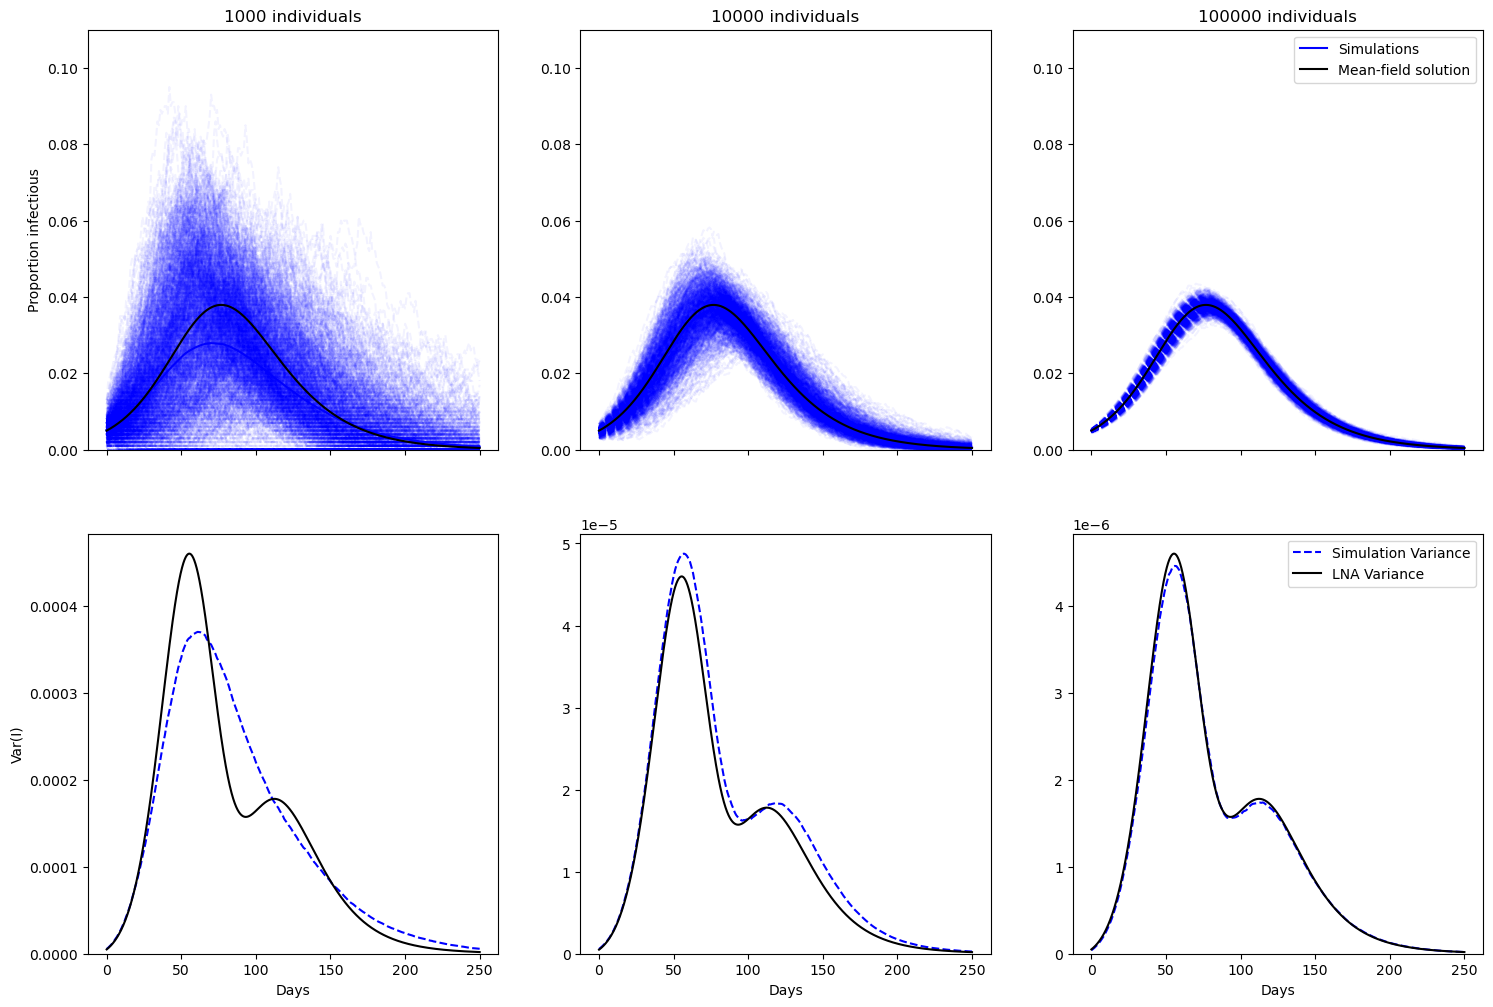

In [45]:
fig, axs = plt.subplots(2, 3, figsize=(18, 12), sharex=True)
axs[0,0].plot(days, df_1000.values[:,::10], color = 'b', linestyle = '--', alpha = 0.05)
axs[0,0].plot(days, df_1000.mean(axis = 1), color = 'b')
axs[0,0].plot(ts, I, color = 'k')
axs[0,1].plot(days, df_10000.values[:,::10], color = 'b', linestyle = '--', alpha = 0.05)
axs[0,1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[0,1].plot(ts, I, color = 'k')
axs[0,2].plot(days, df_100000.values[:,::10], color = 'b', linestyle = '--', alpha = 0.05)
axs[0,2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[0,2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[1,0].plot(days, df_1000_var, color = 'b', linestyle = '--')
axs[1,0].plot(ts, Sigma22/1000, color = 'k')
axs[1,1].plot(days, df_10000_var, color = 'b', linestyle = '--')
axs[1,1].plot(ts, Sigma22/10000, color = 'k')
axs[1,2].plot(days, df_100000_var, color = 'b', linestyle = '--', label = 'Simulation Variance')
axs[1,2].plot(ts, Sigma22/100000, color = 'k', label='LNA Variance')
pop_size = [1000,10000,100000]
row_title = ['Proportion infectious','Var(I)']
for j in range(3):
    axs[0,j].set_ylim(0,0.11)
    axs[1,j].set_ylim(0,None)
    axs[0,j].set_title(f'{pop_size[j]} individuals')
    axs[1,j].set_xlabel('Days')
    if j == 2:
        axs[0,j].legend()
        axs[1,j].legend()
for i in range(2):
    axs[i,0].set_ylabel(row_title[i])
plt.show()

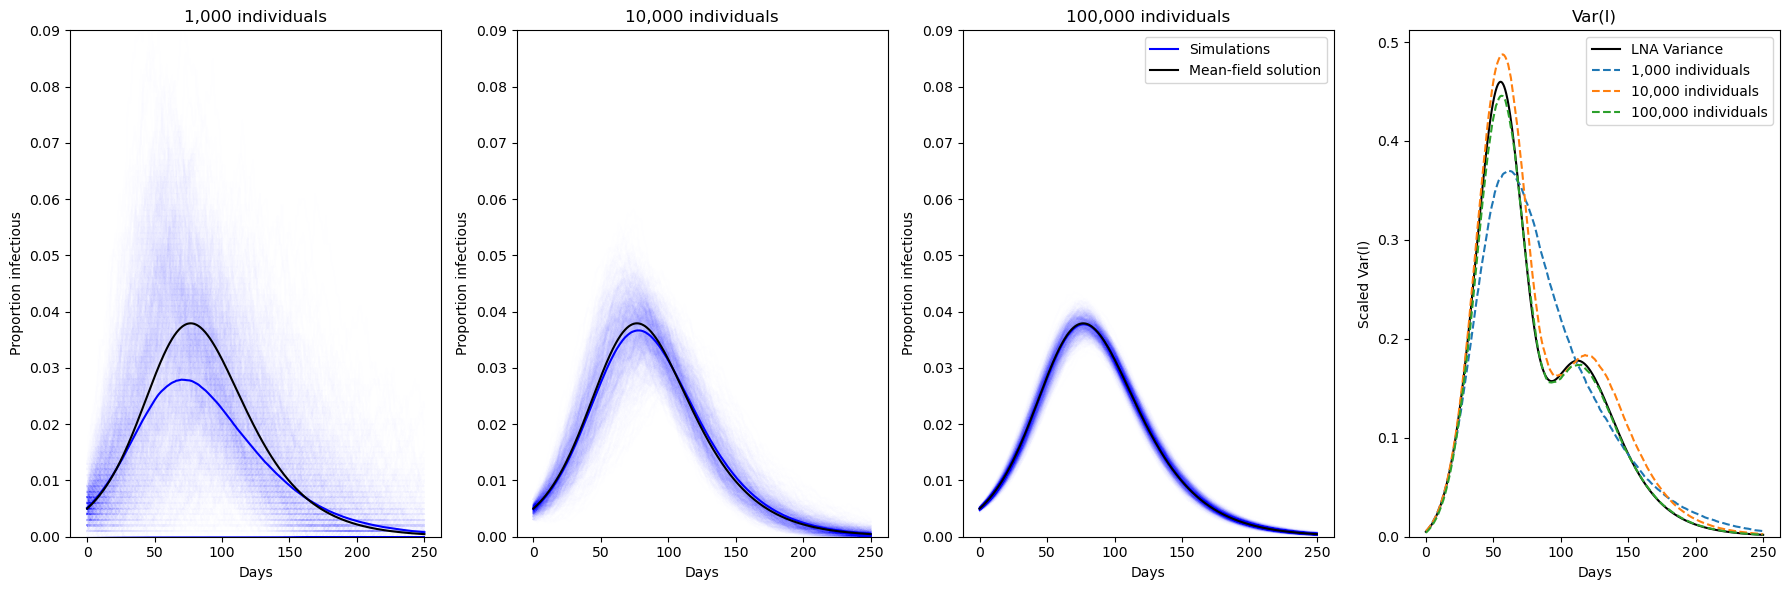

In [46]:
fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, df_1000.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, df_1000.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_10000.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_10000.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_100000.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_100000.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigma22, color = 'k', label='LNA Variance')
axs[3].plot(days, df_1000_var*1000, linestyle = '--', label = '1,000 individuals')
axs[3].plot(days, df_10000_var*10000, linestyle = '--', label = '10,000 individuals')
axs[3].plot(days, df_100000_var*100000, linestyle = '--', label = '100,000 individuals')
pop_size = ['1,000','10,000','100,000']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.09),(0,0.09),(0,0.09),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]} individuals')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()

In [47]:
file_list = glob.glob('Sim_results/highnorm/10000/0.1/I*.npy')
for i, file in enumerate(file_list):
    low_n = np.load(file) if i == 0 else np.vstack((low_n,np.load(file)))
low_n = low_n / 1000
df_1 = pd.DataFrame(low_n).T
stoch_cst = df_1.sub(df_1.mean(axis = 1), axis = 'rows')
df_1_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/highnorm/10000/0.25/I*.npy')
for i, file in enumerate(file_list):
    med_n = np.load(file) if i == 0 else np.vstack((med_n,np.load(file)))
med_n = med_n / 10000
df_25 = pd.DataFrame(med_n).T
stoch_cst = df_25.sub(df_25.mean(axis = 1), axis = 'rows')
df_25_var = stoch_cst.var(axis=1).values
file_list = glob.glob('Sim_results/highnorm/10000/0.5/I*.npy')
for i, file in enumerate(file_list):
    high_n = np.load(file) if i == 0 else np.vstack((high_n,np.load(file)))
high_n = high_n / 100000
df_5 = pd.DataFrame(high_n).T
stoch_cst = df_5.sub(df_5.mean(axis = 1), axis = 'rows')
df_5_var = stoch_cst.var(axis=1).values

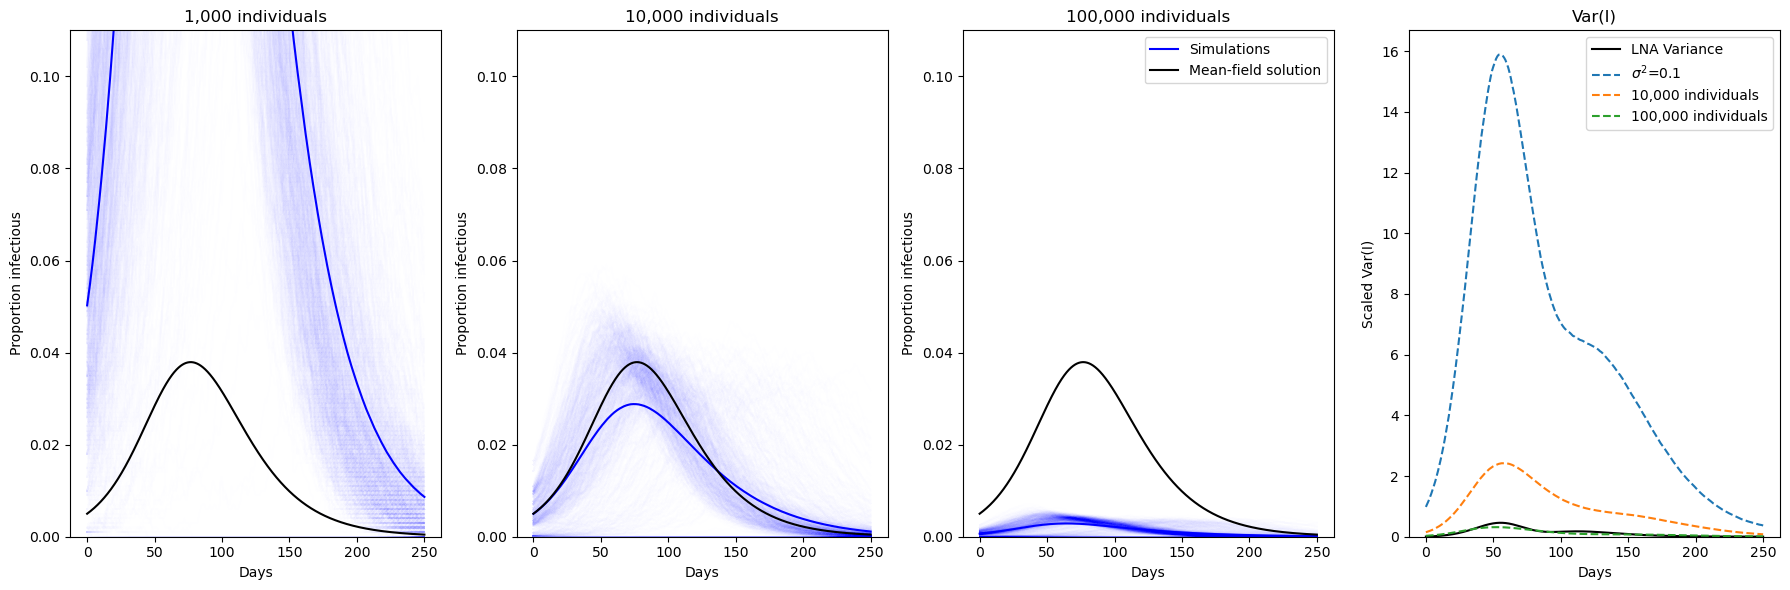

In [48]:
fig, axs = plt.subplots(1, 4, figsize=(18, 6), sharex=True)
axs[0].plot(days, df_1.values[:,::10], color = 'b', alpha = 0.005)
axs[0].plot(days, df_1.mean(axis = 1), color = 'b')
axs[0].plot(ts, I, color = 'k')
axs[1].plot(days, df_25.values[:,::10], color = 'b', alpha = 0.005)
axs[1].plot(days, df_25.mean(axis = 1), color = 'b')
axs[1].plot(ts, I, color = 'k')
axs[2].plot(days, df_5.values[:,::10], color = 'b', alpha = 0.005)
axs[2].plot(days, df_5.mean(axis = 1), color = 'b', label = 'Simulations')
axs[2].plot(ts, I, color = 'k', label = 'Mean-field solution')
axs[3].plot(ts, Sigma22, color = 'k', label='LNA Variance')
axs[3].plot(days, df_1_var*1000, linestyle = '--', label = f'$\sigma^2$=0.1')
axs[3].plot(days, df_25_var*10000, linestyle = '--', label = '10,000 individuals')
axs[3].plot(days, df_5_var*100000, linestyle = '--', label = '100,000 individuals')
pop_size = ['1,000','10,000','100,000']
row_title = ['Proportion infectious','Proportion infectious','Proportion infectious','Scaled Var(I)']
y_lims = [(0,0.11),(0,0.11),(0,0.11),(0,None)]
for j in range(4):
    axs[j].set_ylim(y_lims[j])
    if j != 3:
        axs[j].set_title(f'{pop_size[j]} individuals')
    else:
        axs[j].set_title('Var(I)')    
    axs[j].set_xlabel('Days')
    if ((j == 2) or (j==3)):
        axs[j].legend()
        axs[j].legend()
for i in range(4):
    axs[i].set_ylabel(row_title[i])
plt.tight_layout()
plt.show()